In [58]:
!uv pip install pandas numpy matplotlib seaborn scikit-learn

Checked 5 packages in 1ms


In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [60]:
df_listings = pd.read_csv('listing.csv.gz')

In [61]:
df_listings.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,114543,https://www.airbnb.com/rooms/114543,20260616211535,2026-06-21,city scrape,Charming 55m² flat - Eiffel Tower,Fully furnished charming flat with lots of spa...,NaN,https://a0.muscache.com/pictures/airflow/Hosti...,581233,...,4.97,4.93,4.77,7511502831082,NaN,1,1,0,0,0.83
1,115107,https://www.airbnb.com/rooms/115107,20260616211535,2026-06-25,previous scrape,Charming two-bed apartment with balcony,This charming 60 square meter apartment is per...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,379042,...,5.00,4.40,4.40,7511002008206,NaN,2,1,1,0,0.22
2,115655,https://www.airbnb.com/rooms/115655,20260616211535,2026-06-20,city scrape,Family loft with a private courtyard,"Beautiful openplan loft situated in a private,...",NaN,https://a0.muscache.com/pictures/33160696/6171...,584977,...,4.69,4.04,4.40,7511805457226,NaN,1,1,0,0,1.24
3,120494,https://www.airbnb.com/rooms/120494,20260616211535,2026-06-19,city scrape,Romantic Hideout in Paris,"""As full of spirit as the month of May, as gor...",NaN,https://a0.muscache.com/pictures/833324/f66a6b...,606427,...,4.97,4.85,4.75,7511300905786,NaN,1,1,0,0,2.03
4,125686,https://www.airbnb.com/rooms/125686,20260616211535,2026-06-20,city scrape,Studio - République/Canal Saint Martin,"Tiny studio in central Paris, between the Mara...",NaN,https://a0.muscache.com/pictures/2704337/e28df...,624523,...,4.92,4.87,4.69,"Available with a mobility lease only (""bail mo...",NaN,1,1,0,0,0.79


In [62]:
df_listings['price'] = (
    df_listings['price']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .pipe(pd.to_numeric, errors='coerce')
)

In [63]:
df_listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 77679 entries, 0 to 77678
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            77679 non-null  int64  
 1   listing_url                                   77679 non-null  str    
 2   scrape_id                                     77679 non-null  int64  
 3   last_scraped                                  77679 non-null  str    
 4   source                                        77679 non-null  str    
 5   name                                          77679 non-null  str    
 6   description                                   74850 non-null  str    
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   77678 non-null  str    
 9   host_id                                       77679 non-null  int64  
 1

In [64]:
neighborhood_list = df_listings['neighbourhood_cleansed'].unique()
print(neighborhood_list)

<StringArray>
[          'Vaugirard',   'Buttes-Montmartre',            'Gobelins',
            'Entrepôt',               'Opéra',          'Popincourt',
        'Observatoire',      'Hôtel-de-Ville',              'Bourse',
 'Batignolles-Monceau',               'Passy',     'Buttes-Chaumont',
          'Luxembourg',              'Louvre',             'Reuilly',
              'Élysée',            'Panthéon',        'Ménilmontant',
              'Temple',      'Palais-Bourbon']
Length: 20, dtype: str


In [69]:


df_listings['review_scores_rating'] = pd.to_numeric(
    df_listings['review_scores_rating'],
    errors='coerce'
)
df_listings['price_per_score'] = df_listings['price'] / df_listings['review_scores_rating']

neighborhood_overview = (
    df_listings.groupby('neighbourhood_cleansed')
    .agg({
        'id': 'count',
        'price': 'mean',
        'review_scores_rating': 'mean',
        'price_per_score': 'mean'
    })
    .reset_index()
)


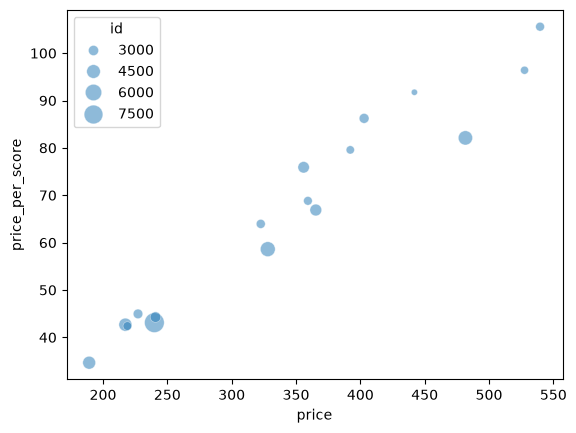

In [71]:
plot = sns.scatterplot(
    data=neighborhood_overview,
    x='price',
    y='price_per_score',
    size='id',
    sizes=(20, 200),
    alpha=0.5
)

In [77]:
neighborhood_overview.sort_values('price_per_score', ascending=False)

,neighbourhood_cleansed,id,price,review_scores_rating,price_per_score
15,Popincourt,6899,245.774612,4.768487,inf
18,Vaugirard,6224,275.834755,4.740989,inf
4,Entrepôt,5330,263.376212,4.752439,inf
19,Élysée,2569,539.669695,4.717645,105.584063
12,Palais-Bourbon,2320,527.594754,4.728839,96.388777
7,Louvre,1862,441.998109,4.741942,91.744787
1,Bourse,2894,402.913117,4.695191,86.228790
14,Passy,4817,481.648860,4.743550,82.109325
8,Luxembourg,2400,392.169015,4.722419,79.578275
17,Temple,3511,355.909087,4.724777,75.904145
